# Preprocessing

A differenza di dataset come NPPAD dove le simulazioni iniziano già in stato anomalo, ogni file SKAB contiene una parte iniziale normale seguita da una zona anomala. La strategia adottata è quindi **per-file**: per ciascun file, la parte con `anomaly==0` viene usata come training set del modello, e l'intera sequenza viene poi usata per la valutazione. Questo garantisce che il modello impari la distribuzione normale nelle stesse condizioni operative in cui avviene l'anomalia.

In [4]:
import pandas as pd
import numpy as np
import os
import pickle
from sklearn.preprocessing import StandardScaler

DATA_PATH = "SKAB/data"

features = ['Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 
            'Pressure', 'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS']

# Raccogliamo tutti i file anomali
all_files = []
for folder in ["valve1", "valve2", "other"]:
    folder_path = os.path.join(DATA_PATH, folder)
    for f in sorted(os.listdir(folder_path)):
        if f.endswith(".csv"):
            all_files.append(os.path.join(folder_path, f))

print(f"Totale file: {len(all_files)}")

# Verifichiamo che ogni file abbia una parte normale
for fpath in all_files:
    df = pd.read_csv(fpath, sep=";")
    n_normal = (df["anomaly"] == 0).sum()
    n_anomaly = (df["anomaly"] == 1).sum()
    print(f"{fpath.split('/')[-2]}/{fpath.split('/')[-1]}: {n_normal} normali, {n_anomaly} anomali")

Totale file: 34
valve1/0.csv: 746 normali, 401 anomali
valve1/1.csv: 743 normali, 402 anomali
valve1/10.csv: 745 normali, 401 anomali
valve1/11.csv: 742 normali, 399 anomali
valve1/12.csv: 741 normali, 399 anomali
valve1/13.csv: 741 normali, 399 anomali
valve1/14.csv: 740 normali, 399 anomali
valve1/15.csv: 746 normali, 404 anomali
valve1/2.csv: 738 normali, 337 anomali
valve1/3.csv: 744 normali, 404 anomali
valve1/4.csv: 746 normali, 349 anomali
valve1/5.csv: 751 normali, 403 anomali
valve1/6.csv: 749 normali, 405 anomali
valve1/7.csv: 689 normali, 405 anomali
valve1/8.csv: 744 normali, 400 anomali
valve1/9.csv: 746 normali, 402 anomali
valve2/0.csv: 731 normali, 394 anomali
valve2/1.csv: 730 normali, 333 anomali
valve2/2.csv: 734 normali, 395 anomali
valve2/3.csv: 600 normali, 395 anomali
other/1.csv: 557 normali, 188 anomali
other/10.csv: 741 normali, 586 anomali
other/11.csv: 739 normali, 451 anomali
other/12.csv: 739 normali, 309 anomali
other/13.csv: 658 normali, 265 anomali
othe

## Analisi delle feature

Analizziamo varianza e struttura delle feature sul file `anomaly-free.csv`. Con 8 feature tutte a varianza significativa e nessuna costante, non è necessaria una riduzione dimensionale aggressiva — a differenza di NPPAD con 97 feature.

Varianza per feature:
Voltage                120.573103
Volume Flow RateRMS      2.577074
Thermocouple             0.533973
Temperature              0.445034
Current                  0.236652
Pressure                 0.064177
Accelerometer1RMS        0.000022
Accelerometer2RMS        0.000016
dtype: float64


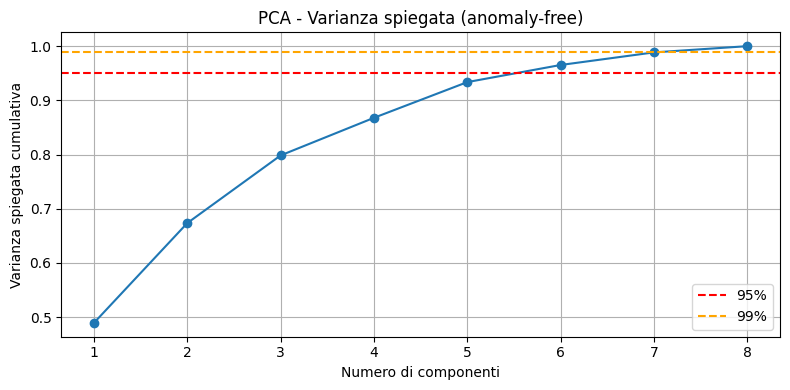

Componenti per 95%: 6
Componenti per 99%: 8


In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Usiamo anomaly-free per l'analisi esplorativa
df_normal = pd.read_csv(os.path.join(DATA_PATH, "anomaly-free/anomaly-free.csv"), sep=";")

# Varianza delle feature
variances = df_normal[features].var().sort_values(ascending=False)
print("Varianza per feature:")
print(variances)

# PCA esplorativa
scaler_exp = StandardScaler()
X_exp = scaler_exp.fit_transform(df_normal[features].values)

pca_full = PCA()
pca_full.fit(X_exp)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumvar)+1), cumvar, marker='o')
plt.axhline(y=0.95, color='red', linestyle='--', label='95%')
plt.axhline(y=0.99, color='orange', linestyle='--', label='99%')
plt.xlabel("Numero di componenti")
plt.ylabel("Varianza spiegata cumulativa")
plt.title("PCA - Varianza spiegata (anomaly-free)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Componenti per 95%: {np.argmax(cumvar >= 0.95) + 1}")
print(f"Componenti per 99%: {np.argmax(cumvar >= 0.99) + 1}")

## Salvataggio

Salviamo la lista dei file e delle feature in `preprocessing.pkl` da riutilizzare in tutti i notebook successivi.

In [6]:
import pickle

features = ['Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 
            'Pressure', 'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS']

all_files = []
for folder in ["valve1", "valve2", "other"]:
    folder_path = os.path.join(DATA_PATH, folder)
    for f in sorted(os.listdir(folder_path)):
        if f.endswith(".csv"):
            all_files.append(os.path.join(folder_path, f))

prep = {
    "features": features,
    "all_files": all_files,
    "data_path": DATA_PATH
}

with open("preprocessing.pkl", "wb") as f:
    pickle.dump(prep, f)

print("Preprocessing salvato!")
print(f"Totale file: {len(all_files)}")

Preprocessing salvato!
Totale file: 34
